<a href="https://colab.research.google.com/github/SantosBruna/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX/blob/main/EBAC_Projeto_Semantix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Parceria | Semantix

A Semantix é uma empresa brasileira fundada em 2010, referência em Big Data, Analytics e Inteligência Artificial na América Latina. Com presença em diversos países das Américas, a companhia desenvolve soluções data driven para organizações que buscam transformar dados em inteligência e vantagem competitiva.

Seu portfólio inclui plataformas Big Data All-in-One, que integram coleta, processamento, análise e visualização de dados em ambientes complexos. A Semantix atua em diferentes setores — como finanças, saúde, varejo e telecomunicações — oferecendo soluções que combinam machine learning, governança de dados e automação.

O objetivo da empresa é ajudar clientes a estarem sempre um passo à frente, utilizando o que há de mais atual em tecnologia para gerar insights estratégicos e melhorar a tomada de decisão.

## PROJETO PARA CIENTISTA DE DADOS - EBAC + SEMANTIX

**Título do Trabalho:** Predição de Satisfação de Passageiros Aéreos: Análise de Fatores Comportamentais e Demográficos que influênciam a Experiência do Cliente em Serviços

**Desenvolvido Por:** Bruna S. R. Santos  
**Iniciado em:** Novembro de 2025

---

## 1. Definição da Problemática

### Contexto e Relevância:

No setor de aviação comercial, a satisfação do passageiro é o principal
indicador de sucesso e fidelização. Estudos demonstram que:

* **89% dos passageiros trocam** de companhia aérea após uma experiência negativa
* Cada passageiro insatisfeito compartilha sua experiência com 15+ pessoas
* O custo de aquisição de novo cliente é 5-7x maior que reter um existente
* Atrasos de voo geram impacto econômico global de bilhões de dólares/ano

Em um mercado de aviação cada vez mais competitivo, entender quais fatores
predizem satisfação permite que companhias aéreas:
* Atuem proativamente antes da insatisfação do passageiro
* **Personalizem experiências** baseadas em perfis comportamentais
* Personalizem serviços baseados em perfis de clientes
* Priorizem melhorias com maior impacto na satisfação
* Reduzam churn identificando passageiros em risco
* Otimizem alocação de recursos em serviços críticos


### Problema Específico a Resolver:

**"Como prever o nível de satisfação de passageiros aéreos baseado em
características demográficas, tipo de viagem, classe de cabine, atrasos
de voo e avaliações de serviços prestados, utilizando machine learning
para identificar os fatores mais críticos e criar sistemas de alerta de
risco de insatisfação?"**

### Objetivo Geral:

Desenvolver um modelo preditivo de satisfação do passageiro (Satisfied vs
Neutral or Dissatisfied) que permita:
1. Identificar passageiros com alto risco de insatisfação
2. Compreender quais fatores mais impactam a experiência
3. Gerar recomendações personalizadas de melhoria de serviço
4. Criar sistema de alerta para intervenção proativa
5. Quantificar impacto de atrasos na satisfação

### Diferencial do Projeto:

Este projeto posiciona-se na intersecção de:
* **Ciência de Dados Aplicada:** Uso de ML para problema real de negócio
* **Customer Experience:** Fundamentos de satisfação e comportamento do cliente
* **Analytics Prescritivo:** Não apenas prever, mas recomendar ações


---




In [2]:
!git clone https://github.com/SantosBruna/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX

Cloning into 'PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 68 (delta 23), reused 28 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 5.82 MiB | 16.69 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [3]:
%cd /content/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX

/content/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX


In [4]:
pip install xgboost

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import src.plot_utils as pu
import src.data_utils as du
import src.model_utils as mu
from importlib import reload
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'airline-passenger-satisfaction' dataset.
Path to dataset files: /kaggle/input/airline-passenger-satisfaction


Para verificar se baixou corretamente

In [7]:
import pandas as pd

# Carregar
df = pd.read_csv('base/train.csv')

# Verificar
print(f"✅ Shape: {df.shape}")
print(f"✅ Colunas: {df.columns.tolist()}")
print(df['satisfaction'].value_counts())

✅ Shape: (103904, 25)
✅ Colunas: ['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


### Campos do Dataset:
* **Gênero:** Sexo dos passageiros (Feminino, Masculino)

* **Tipo de cliente:** O tipo de cliente (Cliente fiel, cliente infiel)

* **Idade:** A idade real dos passageiros

* **Tipo de viagem:** Finalidade do voo dos passageiros (Viagem pessoal, Viagem a negócios)

* **Classe:** Classe de viagem na aeronave dos passageiros (Executiva, Econômica, Econômica Plus)

* **Distância de voo:** A distância de voo desta viagem

* **Serviço de Wi-Fi a bordo:** Nível de satisfação com o serviço de Wi-Fi a bordo (0: Não aplicável; 1-5)

* **Horário de partida/chegada conveniente:** Nível de satisfação com o horário de partida/chegada conveniente.

* **Facilidade de reserva online:** Nível de satisfação com a reserva online

* **Localização do portão:** Nível de satisfação com a localização do portão

* **Comida e bebida:** Nível de satisfação com a comida e bebida

* **Embarque online:** Nível de satisfação com o embarque online

* **Conforto do assento:** Nível de satisfação com o conforto do assento

* **Entretenimento a bordo:** Nível de satisfação com o entretenimento a bordo

* **Serviço de bordo:** Nível de satisfação com o serviço de bordo

* **Serviço de espaço para as pernas:** Nível de satisfação com o serviço de espaço para as pernas

* **Manuseio de bagagem:** Nível de satisfação com o manuseio de bagagem

* **Serviço de check-in:** Nível de satisfação com o serviço de check-in

* **Serviço de bordo:** Nível de satisfação com o serviço de bordo

* **Limpeza:** Nível de satisfação com a limpeza

* **Atraso na partida em minutos:** Minutos de atraso na partida

* **Atraso na chegada em minutos:** Minutos de atraso em relação à chegada.

* **Satisfação:** Nível de satisfação com a companhia aérea (Satisfação, neutro ou insatisfação)

### Tipos de dados:
* Unnamed                               **(int64)** - ID do CSV
* id                                    **(int64)** - ID dos dados
* Gender                                **(object)** - Genero
* Customer Type                         **(object)** - Tipo de Cliente
* Age                                   **(int64)** - Idade
* Type of Travel                        **(object)** - Tipo de Viagem
* Class                                 **(object)** - Classe
* Flight Distance                       **(int64)**- Distancia do voo
* Inflight wifi service                 **(int64)** - Serviço de wifi no voo
* Departure/Arrival time convenient     **(int64)** - Horario de partida/chegada conveniente
* Ease of Online booking                **(int64)** - Facilidade de reserva online
* Gate location                         **(int64)** - Localização do portão
* Food and drink                        **(int64)** - Comida e bebida
* Online boarding                       **(int64)** - Embarque online
* Seat comfort                          **(int64)** - Conforto das cadeiras
* Inflight entertainment                **(int64)** - Entreterimento no voo
* On-board service                      **(int64)** - serviço de bordo
* Leg room service                      **(int64)** - serviço de espaço para as pernas
* Baggage handling                      **(int64)** - Manuseio da bagagem
* Checkin service                       **(int64)** - serviço de check in
* Inflight service                      **(int64)** - serviço de voo
* Cleanliness                           **(int64)** - limpeza
* Departure Delay in Minutes            **(int64)** - Atraso na partida
* Arrival Delay in Minutes              **(float64)** - Atraso na chegada
* satisfaction                          **(object)** - Satisfação

In [8]:
df.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


In [9]:
# Análise Inicial, descobrindo como são os dados

print(f"✅ Tipos de dados: {df.dtypes}")
print(f"✅ Dados faltantes: {df.isnull().sum()}")

✅ Tipos de dados: Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                          

#### Ajustando os tipos de cada variável

In [10]:
df['Gender'] = df['Gender'].astype(str)
df['Customer Type'] = df['Customer Type'].astype(str)
df['Type of Travel'] = df['Type of Travel'].astype(str)
df['Class'] = df['Class'].astype(str)
df['satisfaction'] = df['satisfaction'].astype(str)

print(f'Tipagem:\n {df.dtypes}')

Tipagem:
 Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64


#### Verificando se há dados nulos e corrigindo

In [11]:
(df.isnull().sum() / len(df)) * 100

,0
Unnamed: 0,0.000000
id,0.000000
Gender,0.000000
Customer Type,0.000000
Age,0.000000
Type of Travel,0.000000
Class,0.000000
Flight Distance,0.000000
Inflight wifi service,0.000000
Departure/Arrival time convenient,0.000000


In [12]:
df['Arrival Delay in Minutes'].unique()

array([1.800e+01, 6.000e+00, 0.000e+00, 9.000e+00, 2.300e+01, 8.000e+00,
       3.500e+01, 5.100e+01, 1.000e+01, 5.000e+00, 4.000e+00, 2.900e+01,
       4.400e+01, 2.800e+01, 1.200e+01, 1.200e+02, 2.400e+01, 1.000e+00,
       2.000e+01, 3.100e+01, 1.500e+01, 4.800e+01, 2.600e+01, 4.900e+01,
       2.000e+00, 3.700e+01, 5.000e+01, 3.000e+00, 1.900e+01, 7.200e+01,
       1.100e+01, 3.400e+01, 6.200e+01, 2.700e+01, 5.200e+01, 1.300e+01,
       8.200e+01, 3.000e+01, 1.600e+01, 7.000e+00, 1.220e+02, 1.790e+02,
       1.250e+02, 1.700e+01,       nan, 8.900e+01, 1.010e+02, 1.400e+01,
       6.100e+01, 3.200e+01, 3.300e+01, 4.100e+01, 1.910e+02, 1.380e+02,
       5.300e+01, 2.200e+01, 5.700e+01, 6.500e+01, 7.600e+01, 1.070e+02,
       9.200e+01, 1.640e+02, 2.100e+01, 4.000e+01, 5.500e+01, 1.850e+02,
       6.300e+01, 7.700e+01, 8.600e+01, 9.100e+01, 1.000e+02, 5.400e+01,
       3.600e+01, 7.000e+01, 1.390e+02, 6.700e+01, 1.630e+02, 1.280e+02,
       1.800e+02, 9.300e+01, 1.210e+02, 4.500e+01, 

In [13]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    0
)

In [14]:
df['Arrival Delay in Minutes'].unique()

array([1.800e+01, 6.000e+00, 0.000e+00, 9.000e+00, 2.300e+01, 8.000e+00,
       3.500e+01, 5.100e+01, 1.000e+01, 5.000e+00, 4.000e+00, 2.900e+01,
       4.400e+01, 2.800e+01, 1.200e+01, 1.200e+02, 2.400e+01, 1.000e+00,
       2.000e+01, 3.100e+01, 1.500e+01, 4.800e+01, 2.600e+01, 4.900e+01,
       2.000e+00, 3.700e+01, 5.000e+01, 3.000e+00, 1.900e+01, 7.200e+01,
       1.100e+01, 3.400e+01, 6.200e+01, 2.700e+01, 5.200e+01, 1.300e+01,
       8.200e+01, 3.000e+01, 1.600e+01, 7.000e+00, 1.220e+02, 1.790e+02,
       1.250e+02, 1.700e+01, 8.900e+01, 1.010e+02, 1.400e+01, 6.100e+01,
       3.200e+01, 3.300e+01, 4.100e+01, 1.910e+02, 1.380e+02, 5.300e+01,
       2.200e+01, 5.700e+01, 6.500e+01, 7.600e+01, 1.070e+02, 9.200e+01,
       1.640e+02, 2.100e+01, 4.000e+01, 5.500e+01, 1.850e+02, 6.300e+01,
       7.700e+01, 8.600e+01, 9.100e+01, 1.000e+02, 5.400e+01, 3.600e+01,
       7.000e+01, 1.390e+02, 6.700e+01, 1.630e+02, 1.280e+02, 1.800e+02,
       9.300e+01, 1.210e+02, 4.500e+01, 1.050e+02, 

In [15]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].astype(int)

In [16]:
colunas = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

# Loop para mostrar os valores únicos de cada coluna
for col in colunas:
    print(f"\nValores únicos da coluna '{col}':")
    print(df[col].unique())


Valores únicos da coluna 'Gender':
['Male' 'Female']

Valores únicos da coluna 'Customer Type':
['Loyal Customer' 'disloyal Customer']

Valores únicos da coluna 'Type of Travel':
['Personal Travel' 'Business travel']

Valores únicos da coluna 'Class':
['Eco Plus' 'Business' 'Eco']

Valores únicos da coluna 'satisfaction':
['neutral or dissatisfied' 'satisfied']


#### Segunda etapa do pré processamento: Análise de outiliers, univariada e bivariada

In [17]:
df.describe().round(2)

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00,103904.00
mean,51951.50,64924.21,39.38,1189.45,2.73,3.06,2.76,2.98,3.20,3.25,3.44,3.36,3.38,3.35,3.63,3.30,3.64,3.29,14.82,15.13
std,29994.65,37463.81,15.11,997.15,1.33,1.53,1.40,1.28,1.33,1.35,1.32,1.33,1.29,1.32,1.18,1.27,1.18,1.31,38.23,38.65
min,0.00,1.00,7.00,31.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,25975.75,32533.75,27.00,414.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,3.00,3.00,2.00,0.00,0.00
50%,51951.50,64856.50,40.00,843.00,3.00,3.00,3.00,3.00,3.00,3.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00,0.00,0.00
75%,77927.25,97368.25,51.00,1743.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,4.00,4.00,5.00,4.00,5.00,4.00,12.00,13.00
max,103903.00,129880.00,85.00,4983.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1592.00,1584.00


In [18]:
du.comparar_media_mediana(df)

,média,mediana,diferença
Unnamed: 0,51951.500000,51951.5,0.000000
id,64924.210502,64856.5,67.710502
Age,39.379706,40.0,-0.620294
Flight Distance,1189.448375,843.0,346.448375
Inflight wifi service,2.729683,3.0,-0.270317
Departure/Arrival time convenient,3.060296,3.0,0.060296
Ease of Online booking,2.756901,3.0,-0.243099
Gate location,2.976883,3.0,-0.023117
Food and drink,3.202129,3.0,0.202129
Online boarding,3.250375,3.0,0.250375


In [19]:
du.comparar_75_max(df)

,75%,max,diferença
Unnamed: 0,77927.25,103903,25975.75
id,97368.25,129880,32511.75
Age,51.00,85,34.00
Flight Distance,1743.00,4983,3240.00
Inflight wifi service,4.00,5,1.00
Departure/Arrival time convenient,4.00,5,1.00
Ease of Online booking,4.00,5,1.00
Gate location,4.00,5,1.00
Food and drink,4.00,5,1.00
Online boarding,4.00,5,1.00


#### As três variáveis que precisam de mais atenção são:

* Flight Distance
* Departure Delay in Minutes
* Arrival Delay in Minutes

#### Começando com Flisht Distance

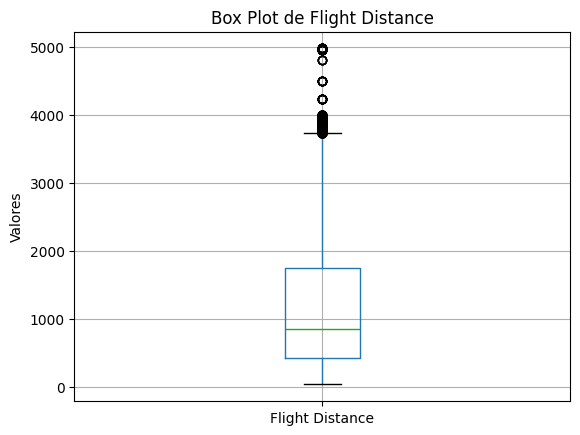

In [20]:
df.boxplot(column='Flight Distance')
plt.title('Box Plot de Flight Distance')
plt.ylabel('Valores')
plt.show()

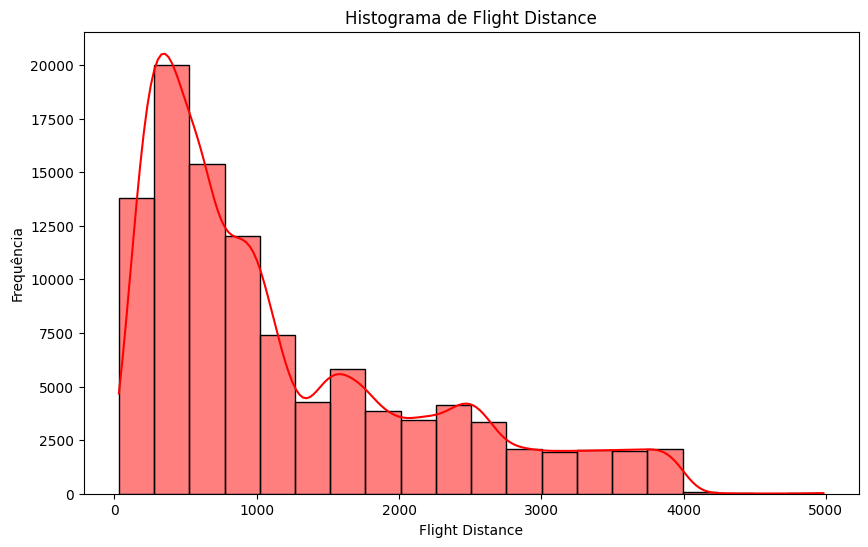

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Flight Distance', bins=20, kde=True, color='red')
plt.title('Histograma de Flight Distance')
plt.xlabel('Flight Distance')
plt.ylabel('Frequência')
plt.show()

In [22]:
# Localizando outiliers
outliers = du.detectar_outliers_iqr(df, 'Flight Distance')
print(outliers['Flight Distance'])
print(len(outliers))   # quantidade de linhas detectadas

80        3960
173       3747
201       3854
215       3753
379       3995
          ... 
103565    3881
103648    3890
103727    3990
103865    3795
103889    3885
Name: Flight Distance, Length: 2291, dtype: int64
2291


In [23]:
import plotly.express as px

fig = px.box(df, y='Flight Distance', title='Box Plot do Flight Distance', labels={'Flight Distance': 'Valores'})
fig.show()

In [24]:
df[df['Flight Distance'] > 3736]

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
80,80,73302,Male,Loyal Customer,26,Business travel,Business,3960,1,1,...,4,4,2,5,4,4,4,45,48,satisfied
173,173,101275,Male,Loyal Customer,52,Business travel,Business,3747,5,5,...,4,4,4,4,5,4,5,24,20,satisfied
201,201,66800,Female,Loyal Customer,43,Business travel,Business,3854,5,5,...,5,5,5,5,5,5,3,0,0,satisfied
215,215,23328,Female,Loyal Customer,38,Business travel,Business,3753,2,2,...,4,4,4,4,4,4,1,0,0,satisfied
379,379,85109,Male,Loyal Customer,46,Business travel,Business,3995,4,4,...,5,5,5,5,5,5,4,0,0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103565,103565,68522,Female,Loyal Customer,59,Business travel,Business,3881,2,2,...,2,2,2,2,5,2,3,0,0,satisfied
103648,103648,38750,Male,Loyal Customer,43,Business travel,Business,3890,4,4,...,5,5,5,5,2,5,2,0,0,satisfied
103727,103727,35286,Female,Loyal Customer,25,Business travel,Business,3990,3,3,...,3,1,4,2,4,3,3,0,12,neutral or dissatisfied
103865,103865,46017,Male,Loyal Customer,35,Business travel,Business,3795,5,5,...,2,2,2,2,2,2,1,0,0,satisfied


#### Analisando a variável Departure Delay in Minutes

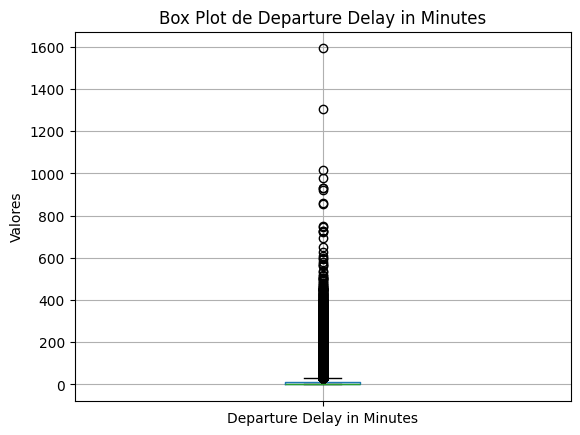

In [25]:
df.boxplot(column='Departure Delay in Minutes')
plt.title('Box Plot de Departure Delay in Minutes')
plt.ylabel('Valores')
plt.show()

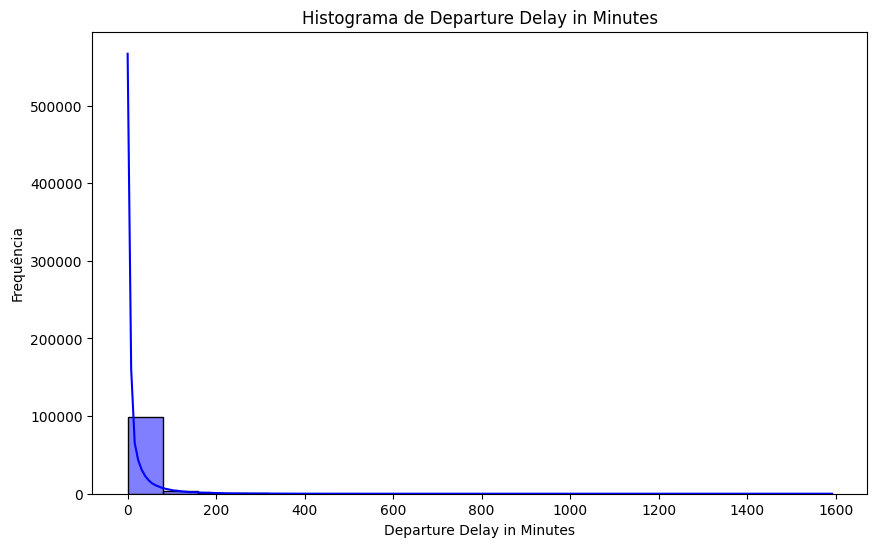

In [26]:
pu.plot_histograma(df, 'Departure Delay in Minutes')

In [27]:
# Localizando outiliers
outliers = du.detectar_outliers_iqr(df, 'Departure Delay in Minutes')
print(outliers['Flight Distance'])
print(len(outliers))   # quantidade de linhas detectadas

14         453
16        2123
22         752
24         452
32        2611
          ... 
103869     895
103881     384
103885     500
103891    1991
103892     596
Name: Flight Distance, Length: 14529, dtype: int64
14529


#### Analisando a variável Arrival Delay in Minutes

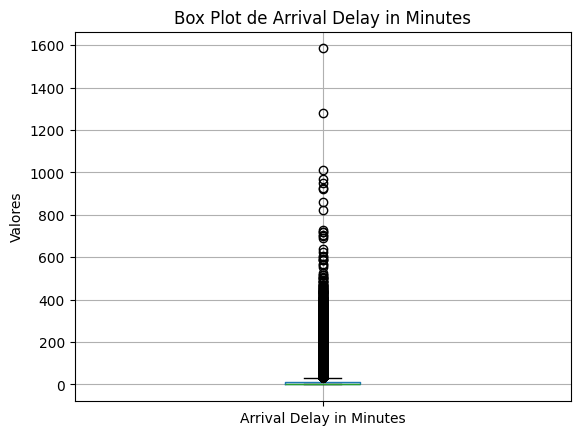

In [28]:
df.boxplot(column='Arrival Delay in Minutes')
plt.title('Box Plot de Arrival Delay in Minutes')
plt.ylabel('Valores')
plt.show()

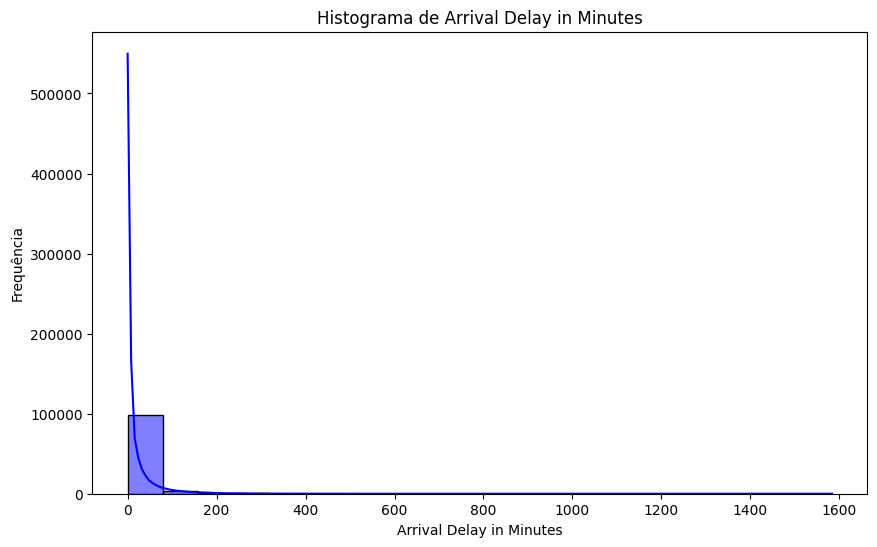

In [29]:
pu.plot_histograma(df, 'Arrival Delay in Minutes')

In [30]:
# Localizando outiliers
outliers = du.detectar_outliers_iqr(df, 'Arrival Delay in Minutes')
print(outliers['Flight Distance'])
print(len(outliers))   # quantidade de linhas detectadas

14         453
16        2123
24         452
32        2611
55        3334
          ... 
103843    1076
103854    2212
103869     895
103881     384
103892     596
Name: Flight Distance, Length: 13954, dtype: int64
13954


#### Depois de verificar os dados das três variáveis cheguei a conclusão de que os dados são legitimos e fazem sentido, não sendo necessário fazer nenhum ajuste.

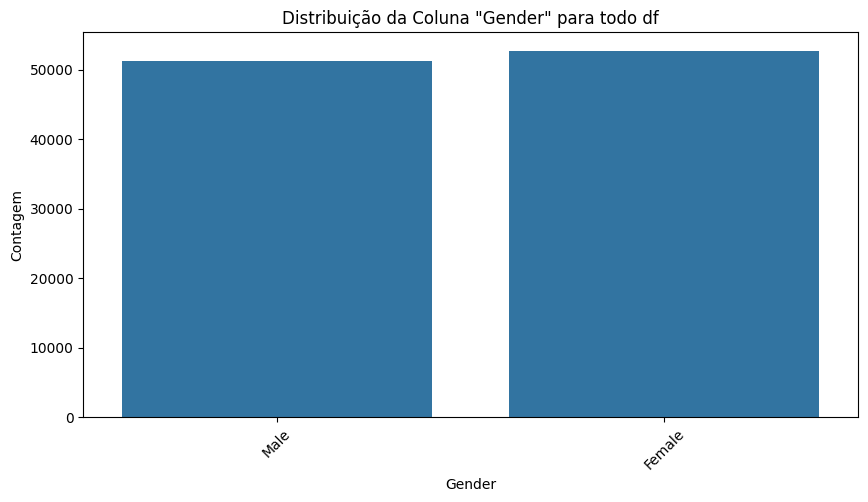

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Gender')
plt.title('Distribuição da Coluna "Gender" para todo df')
plt.xlabel('Gender')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

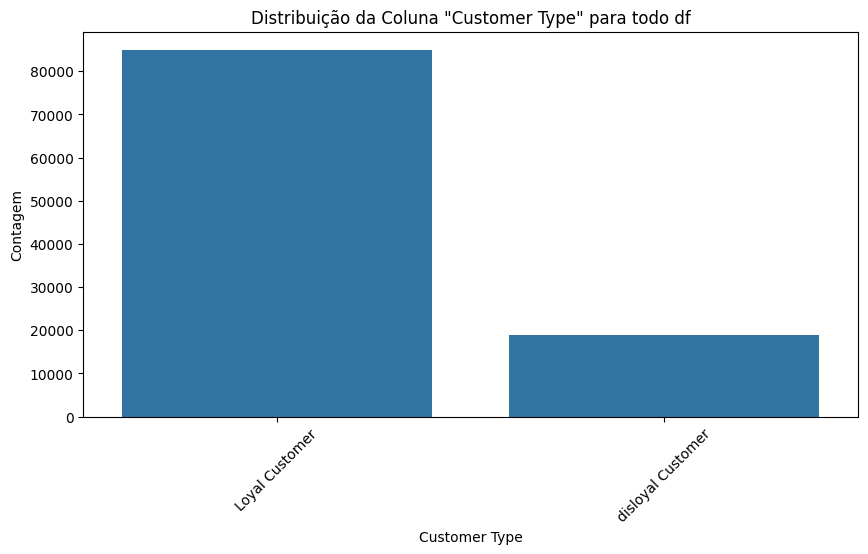

In [32]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Customer Type')
plt.title('Distribuição da Coluna "Customer Type" para todo df')
plt.xlabel('Customer Type')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

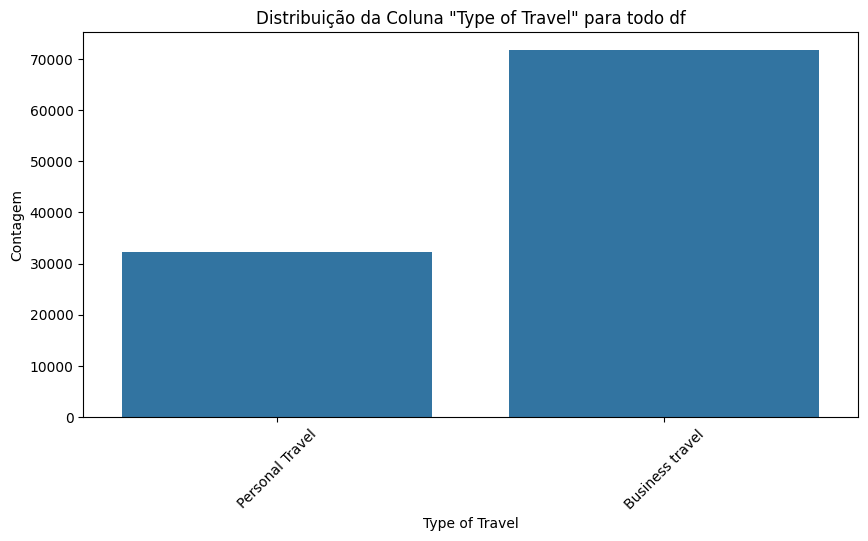

In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Type of Travel')
plt.title('Distribuição da Coluna "Type of Travel" para todo df')
plt.xlabel('Type of Travel')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

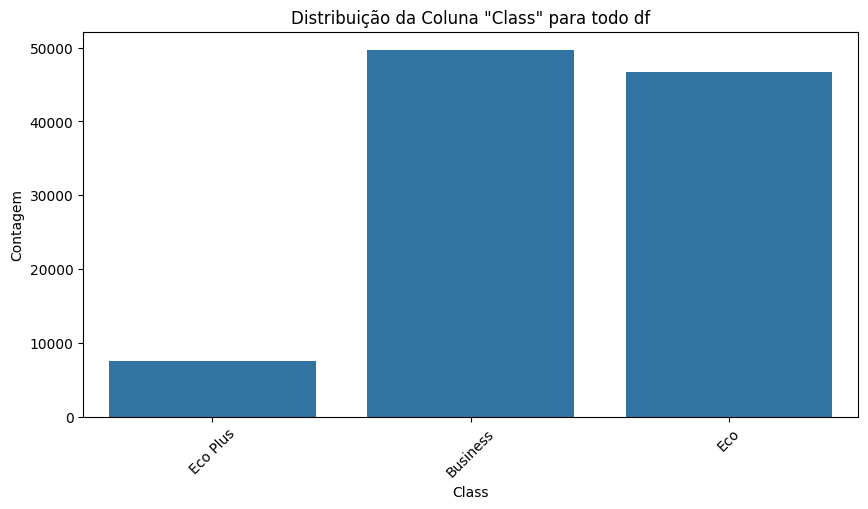

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Class')
plt.title('Distribuição da Coluna "Class" para todo df')
plt.xlabel('Class')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

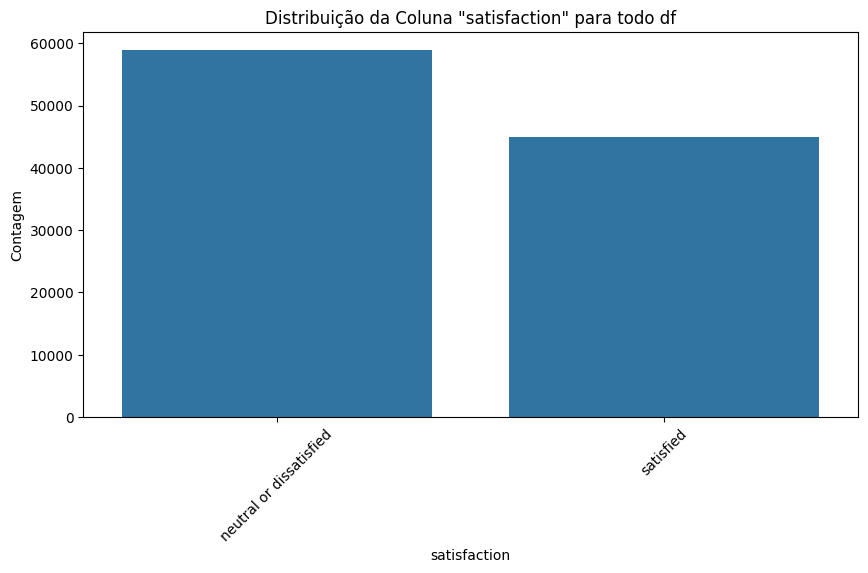

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='satisfaction')
plt.title('Distribuição da Coluna "satisfaction" para todo df')
plt.xlabel('satisfaction')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

#### Análise dos dados até o momento:

- O dataset está com registros sobre genêros em equilibrio
- O tipo de cliente é muito maior para loyal do que disloyal no dataset
- A maior concentração de viagens é á trabalho
- Dos três tipos de classes, a que tem muito pouca quantidade de registros é o Eco Plus
- O target encontra-se levemente desbalanceado para neutro ou insatisfeito.

#### Agora será feito a análise bivariada dos dados

In [36]:
colunas = [
    'Age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes'
]

for col in colunas:
    if df[col].dtype in ['int64', 'float64']:

        # Remove nulos e zeros antes de calcular a mediana
        df_filtrado = df[df[col].notna() & (df[col] > 0)]

        # Calcula a mediana da coluna numérica agrupada pelo target
        mediana = df_filtrado.groupby('satisfaction')[col].median().reset_index()

        fig = px.bar(
            mediana,
            x='satisfaction',
            y=col,
            title=f'Mediana de {col} por Satisfação',
            labels={'satisfaction': 'Satisfação', col: f'Mediana de {col}'},
            color='satisfaction'
        )
        fig.show()

In [37]:
colunas_satisfacao = {
    'Inflight wifi service': 'Serviço de Wi-Fi a bordo',
    'Departure/Arrival time convenient': 'Horário de partida/chegada conveniente',
    'Ease of Online booking': 'Facilidade de reserva online',
    'Gate location': 'Localização do portão',
    'Food and drink': 'Comida e bebida',
    'Online boarding': 'Embarque online',
    'Seat comfort': 'Conforto do assento',
    'Inflight entertainment': 'Entretenimento a bordo',
    'On-board service': 'Serviço de bordo',
    'Leg room service': 'Serviço de espaço para as pernas',
    'Baggage handling': 'Manuseio de bagagem',
    'Checkin service': 'Serviço de check-in',
    'Inflight service': 'Serviço de voo',
    'Cleanliness': 'Limpeza'
}

for col, descricao in colunas_satisfacao.items():

    # Calcula a proporção de cada nível (1-5) por categoria do target
    contagem = (
        df.groupby([col, 'satisfaction'])
        .size()
        .reset_index(name='count')
    )

    # Calcula o percentual dentro de cada nível
    contagem['pct'] = (
        contagem.groupby(col)['count']
        .transform(lambda x: x / x.sum() * 100)
    )

    fig = px.bar(
        contagem,
        x=col,
        y='pct',
        color='satisfaction',
        barmode='group',
        title=f'{descricao} (1-5) vs Satisfação',
        labels={
            col: f'Nível de Satisfação - {descricao}',
            'pct': '% de Passageiros',
            'satisfaction': 'Satisfação'
        },
        text=contagem['pct'].round(1).astype(str) + '%'
    )

    fig.update_layout(
        xaxis=dict(tickmode='linear', dtick=1),
        yaxis_title='% de Passageiros',
        legend_title='Satisfação'
    )

    fig.show()

In [38]:
categoricas = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# Loop para gerar gráficos de barras
for cat in categoricas:

    # Calcula a proporção de satisfeitos por categoria
    contagem = (
        df.groupby([cat, 'satisfaction'])
        .size()
        .reset_index(name='count')
    )

    contagem['pct'] = (
        contagem.groupby(cat)['count']
        .transform(lambda x: x / x.sum() * 100)
    )

    fig = px.bar(
        contagem,
        x=cat,
        y='pct',
        color='satisfaction',
        barmode='group',
        title=f'Distribuição de Satisfação por {cat}',
        labels={
            cat: cat,
            'pct': '% de Passageiros',
            'satisfaction': 'Satisfação'
        },
        text=contagem['pct'].round(1).astype(str) + '%'
    )

    fig.update_layout(
        yaxis_title='% de Passageiros',
        legend_title='Satisfação'
    )

    fig.show()

# 📊 Principais Insights da Análise

- **Perfil etário:** Passageiros satisfeitos tendem a ter idade média em torno de **43 anos**, enquanto os insatisfeitos concentram-se em torno de **36 anos**.  
- **Distância do voo:** Existe uma correlação positiva entre a **distância percorrida** e o nível de satisfação — quanto maior a distância, maior a satisfação.  
- **Pontualidade:**  
  - **Atrasos na partida** aumentam significativamente a insatisfação.  
  - **Atrasos na chegada** também elevam as chances de insatisfação, reforçando a importância da pontualidade.  

## ✈️ Serviços a bordo
- **Wi-Fi:** níveis **4 e 5** apresentam maior taxa de satisfação, indicando correlação positiva entre qualidade do serviço e satisfação geral. O nível **0 (não aplicável)** também aparece com alta satisfação.  
- **Comida e bebida:** níveis **4 e 5** concentram os passageiros mais satisfeitos.  
- **Entretenimento, serviço de bordo e espaço para pernas:** satisfação elevada apenas nos níveis **4 e 5**.  
- **Conforto dos assentos:** níveis **4 e 5** apresentam os maiores índices de satisfação.  
- **Manuseio da bagagem, check-in e serviço de voo:** apenas o nível **5** mostra alta satisfação.  
- **Limpeza:** níveis **4 e 5** concentram maior satisfação.  

## 🛫 Processos de viagem
- **Horário de partida/chegada conveniente:** todos os níveis apresentam maior proporção de insatisfeitos, sugerindo oportunidade de melhoria.  
- **Facilidade de reserva:** correlação positiva com satisfação; níveis **4 e 5** concentram maior satisfação.  
- **Localização do portão:** alta satisfação apenas nos níveis **0 (não aplicável)** e **5**, indicando espaço para melhorias intermediárias.  
- **Embarque online:** níveis **4 e 5** apresentam maior satisfação, reforçando a importância da digitalização eficiente.  

## 👥 Perfil do passageiro
- **Gênero:** tanto homens quanto mulheres apresentam maior concentração em neutro ou insatisfeito.  
- **Customer Loyalty:** passageiros recorrentes apresentam menor taxa de insatisfação em comparação aos novos clientes, embora em ambos os casos a insatisfação seja predominante.  
- **Tipo de viagem:** viagens a trabalho têm maior taxa de satisfação do que viagens pessoais.  
- **Classe de cabine:** apenas a **Business Class** apresenta alta taxa de satisfação; nas demais classes, a satisfação é baixa.  

---

## 📌 Conclusão
Os resultados mostram que a **pontualidade, qualidade dos serviços a bordo e processos digitais (reserva e embarque online)** são os principais fatores que influenciam a satisfação dos passageiros. Além disso, o perfil do cliente (idade, fidelidade, tipo de viagem e classe de cabine) desempenha papel relevante na experiência. Esses pontos podem orientar estratégias de melhoria e personalização dos serviços oferecidos pela companhia aérea.


## Agora será feito o tratamento das variáveis categoricas.

In [39]:
print(f'Tipagem:\n {df.dtypes}')

Tipagem:
 Unnamed: 0                            int64
id                                    int64
Gender                               object
Customer Type                        object
Age                                   int64
Type of Travel                       object
Class                                object
Flight Distance                       int64
Inflight wifi service                 int64
Departure/Arrival time convenient     int64
Ease of Online booking                int64
Gate location                         int64
Food and drink                        int64
Online boarding                       int64
Seat comfort                          int64
Inflight entertainment                int64
On-board service                      int64
Leg room service                      int64
Baggage handling                      int64
Checkin service                       int64
Inflight service                      int64
Cleanliness                           int64
Departure Delay in Min

In [40]:
df.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,...,5,5,5,5,4,5,4,4,0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,...,1,1,2,1,4,1,2,0,0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,...,2,2,3,4,4,3,2,0,0,neutral or dissatisfied


In [41]:
# Label Enconder para a coluna genero
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

In [42]:
# Descartando as colunas Unnamed e id
df = df.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['id'])

In [43]:
df['Customer Type'].unique()

array(['Loyal Customer', 'disloyal Customer'], dtype=object)

In [44]:
# Label enconder para a coluna Custumer Type, já que só tem dois tipos

le_customer = LabelEncoder()
df['Customer Type'] = le_customer.fit_transform(df['Customer Type'])

In [45]:
df['Type of Travel'].unique()

array(['Personal Travel', 'Business travel'], dtype=object)

In [46]:
# Label enconder para a coluna Type of Travel, já que só tem dois tipos

le_travel = LabelEncoder()
df['Type of Travel'] = le_travel.fit_transform(df['Type of Travel'])

In [47]:
df['Class'].unique()

array(['Eco Plus', 'Business', 'Eco'], dtype=object)

In [48]:
# Neste caso irei usar o get_dummies, exluindo a primeira opção para evitar multicolinearidade
df = pd.get_dummies(df, columns=['Class'], drop_first=True)

In [49]:
df['satisfaction'].unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [50]:
# Label enconder para a coluna satisfaction, já que só tem dois tipos

le_satisfaction = LabelEncoder()
df['satisfaction'] = le_satisfaction.fit_transform(df['satisfaction'])

In [51]:
df.head(10)

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Eco,Class_Eco Plus
0,1,0,13,1,460,3,4,3,1,5,...,3,4,4,5,5,25,18,0,False,True
1,1,1,25,0,235,3,2,3,3,1,...,5,3,1,4,1,1,6,0,False,False
2,0,0,26,0,1142,2,2,2,2,5,...,3,4,4,4,5,0,0,1,False,False
3,0,0,25,0,562,2,5,5,5,2,...,5,3,1,4,2,11,9,0,False,False
4,1,0,61,0,214,3,3,3,3,4,...,4,4,3,3,3,0,0,1,False,False
5,0,0,26,1,1180,3,4,2,1,1,...,4,4,4,4,1,0,0,0,True,False
6,1,0,47,1,1276,2,4,2,3,2,...,3,4,3,5,2,9,23,0,True,False
7,0,0,52,0,2035,4,3,4,4,5,...,5,5,4,5,4,4,0,1,False,False
8,0,0,41,0,853,1,2,2,2,4,...,2,1,4,1,2,0,0,0,False,False
9,1,1,20,0,1061,3,3,3,4,2,...,3,4,4,3,2,0,0,0,True,False


In [52]:
reload(pu)

<module 'src.plot_utils' from '/content/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX/src/plot_utils.py'>

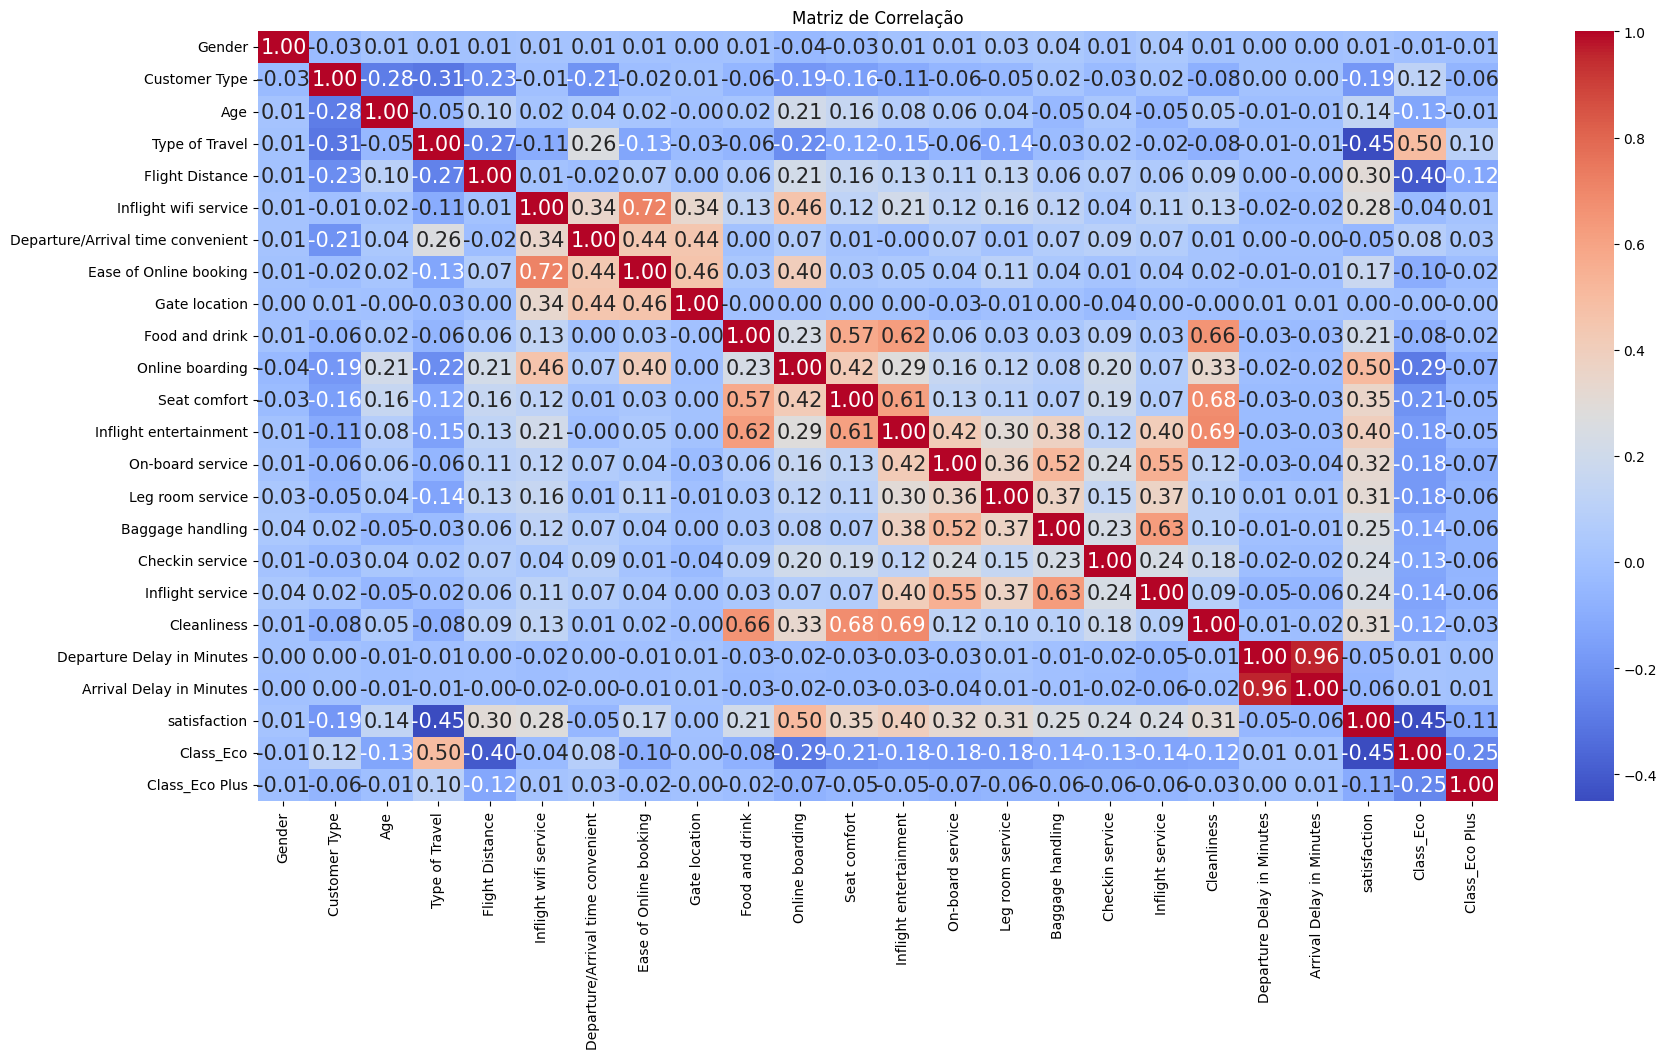

In [53]:
pu.mapa_correlacao(df)

In [54]:
df['satisfaction'] = df['satisfaction'].astype(int)
du.correlacao_com_target(df, 'satisfaction')

,variável,correlação
0,Online boarding,0.503557
1,Inflight entertainment,0.398059
2,Seat comfort,0.349459
3,On-board service,0.322383
4,Leg room service,0.313131
5,Cleanliness,0.305198
6,Flight Distance,0.298780
7,Inflight wifi service,0.284245
8,Baggage handling,0.247749
9,Inflight service,0.244741


In [55]:
du.maiores_correlacoes(df)

,variável_1,variável_2,correlação
0,Arrival Delay in Minutes,Departure Delay in Minutes,0.960247
1,Ease of Online booking,Inflight wifi service,0.715856


In [56]:
reload(du)

<module 'src.data_utils' from '/content/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX/src/data_utils.py'>

In [57]:
# Após a analise da correlação e o tratamento das variáveis categoricas, irei separar as bases e então irei aplicar a redução de dimensionalidade
X, Y = du.separar_x_y(df, 'satisfaction')

In [58]:
Y

,satisfaction
0,0
1,0
2,1
3,0
4,1
...,...
103899,0
103900,1
103901,0
103902,0


In [59]:
X.dtypes

,0
Gender,int64
Customer Type,int64
Age,int64
Type of Travel,int64
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64
Ease of Online booking,int64
Gate location,int64
Food and drink,int64


In [60]:
variaveis = du.listar_colunas(X)
variaveis.remove('Arrival Delay in Minutes') # tem correlação muito alta com a variavel departure Delay in Minutes
variaveis.remove('Gender')
variaveis.remove('Gate location')
variaveis.remove('Departure Delay in Minutes')
variaveis.remove('Departure/Arrival time convenient')
print(variaveis)

['Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Ease of Online booking', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Class_Eco', 'Class_Eco Plus']


In [61]:
print(len(variaveis))

18


In [62]:
X = X[variaveis]

In [63]:
X

,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Ease of Online booking,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Class_Eco,Class_Eco Plus
0,0,13,1,460,3,3,5,3,5,5,4,3,4,4,5,5,False,True
1,1,25,0,235,3,3,1,3,1,1,1,5,3,1,4,1,False,False
2,0,26,0,1142,2,2,5,5,5,5,4,3,4,4,4,5,False,False
3,0,25,0,562,2,5,2,2,2,2,2,5,3,1,4,2,False,False
4,0,61,0,214,3,3,4,5,5,3,3,4,4,3,3,3,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,1,23,0,192,2,2,2,2,2,2,3,1,4,2,3,2,True,False
103900,0,49,0,2347,4,4,2,4,5,5,5,5,5,5,5,4,False,False
103901,1,30,0,1995,1,1,4,1,5,4,3,2,4,5,5,4,False,False
103902,1,22,0,1000,1,1,1,1,1,1,4,5,1,5,4,1,True,False


In [64]:
X_train, X_test, Y_train, Y_test = du.separar_treino_teste(X[variaveis],Y)

In [65]:
print("X_train:", X_train.shape)
print("X_test:",  X_test.shape)
print("y_train:", Y_train.shape)
print("y_test:",  Y_test.shape)

X_train: (83123, 18)
X_test: (20781, 18)
y_train: (83123,)
y_test: (20781,)


In [66]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

pca_exploratório = PCA(n_components=18)
pca_exploratório.fit(X_scaled)

PCA(n_components=18)

In [67]:
# Variância explicada por cada componente
explained_variance = pca_exploratório.explained_variance_ratio_

# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

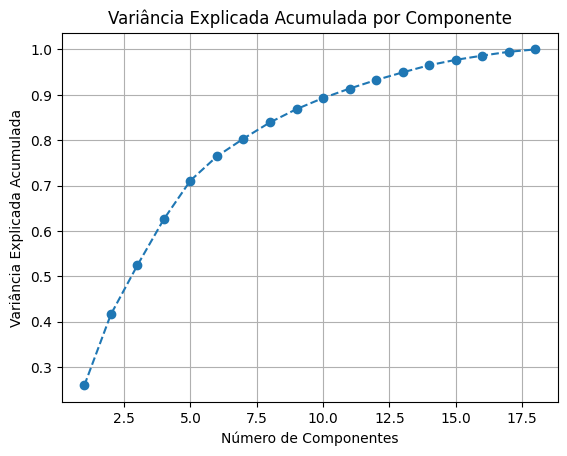

In [68]:
pu.plot_variancia_acumulada(cumulative_variance)

In [69]:
# Variância explicada de cada componente
explained_variance = pca_exploratório.explained_variance_ratio_

# Variância acumulada
cumulative_variance = explained_variance.cumsum()

# Criando tabela
tabela_pca = pd.DataFrame({
    'Componente': range(1, len(explained_variance) + 1),
    'Variância Explicada (%)': (explained_variance * 100).round(2),
    'Variância Acumulada (%)': (cumulative_variance * 100).round(2)
})

# Exibir tabela
print(tabela_pca)

    Componente  Variância Explicada (%)  Variância Acumulada (%)
0            1                    25.97                    25.97
1            2                    15.63                    41.61
2            3                    10.83                    52.44
3            4                    10.18                    62.61
4            5                     8.50                    71.11
5            6                     5.33                    76.44
6            7                     3.90                    80.34
7            8                     3.58                    83.93
8            9                     2.92                    86.85
9           10                     2.44                    89.29
10          11                     2.08                    91.37
11          12                     1.89                    93.26
12          13                     1.68                    94.94
13          14                     1.59                    96.52
14          15           

In [70]:
print(
    tabela_pca[
        tabela_pca['Variância Acumulada (%)'] >= 90
    ].head(1)
)

print(
    tabela_pca[
        tabela_pca['Variância Acumulada (%)'] >= 95
    ].head(1)
)

    Componente  Variância Explicada (%)  Variância Acumulada (%)
10          11                     2.08                    91.37
    Componente  Variância Explicada (%)  Variância Acumulada (%)
13          14                     1.59                    96.52


#### Analisando o PCA podemos ver que com 8 componentes possui uma variancia acumulada de 90.57% com uma variância Explicada de 1.48%, indicando ser a melhor opção. Em seguida temos 9, 10, 11 e 12 componentes com bons valores que poderiam ser escolhidos.

#### O proximo passo é a criação dos modelos. Aqui irei usar a regressão logistica e o XGBoost.

### Regressão logistica

In [71]:
# Pipeline sem Hiperparâmetros
pipeline_lr_simple= mu.criar_pipeline_regressao_logistica(n_components=18)

In [72]:
# Avaliando os resultados
resultado_lr_simple = mu.criar_cross_validation(
    pipeline=pipeline_lr_simple,
    X=X,
    y=Y,
    folds=5,
    scoring='accuracy'
)

Pontuações por fold : [0.86593523 0.86742698 0.86853376 0.86675328 0.86997113]
Média               : 0.8677
Desvio padrão       : 0.0014


In [73]:
# Gera predições cruzadas (cada amostra é predita quando estava no fold de validação)
y_pred_lr_simple = cross_val_predict(
    pipeline_lr_simple,
    X,
    Y,
    cv=resultado_lr_simple['kfold']   # reutiliza o mesmo kfold do resultado
)

# Relatório
relatorio_lr_simple = classification_report(Y, y_pred_lr_simple)
print("Relatório de Classificação — Cross Validation do modelo LR sem Hiper:")
print(relatorio_lr_simple)

Relatório de Classificação — Cross Validation do modelo LR sem Hiper:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     58879
           1       0.84      0.86      0.85     45025

    accuracy                           0.87    103904
   macro avg       0.86      0.87      0.87    103904
weighted avg       0.87      0.87      0.87    103904



In [74]:
# Pipeline que será incluido os hiperparâmetros
pipe_lr_hiper = mu.criar_pipeline_regressao_logistica(
    n_components=13
)

In [75]:
# Define os parâmetros para a regressão logística

param_grid_lr = {
    'pca__n_components': [18],
    'balanceamento__k_neighbors': [10],
    'modelo__C': [0.01],
    'modelo__max_iter': [500],
    'modelo__class_weight': [None]
}

In [76]:
# StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [77]:
# GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=pipe_lr_hiper,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1          # mostra progresso
)

grid_search_lr.fit(X_train, Y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=13)),
                                       ('balanceamento',
                                        SMOTE(random_state=42)),
                                       ('modelo',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'balanceamento__k_neighbors': [10],
                         'modelo__C': [0.01], 'modelo__class_weight': [None],
                         'modelo__max_iter': [500], 'pca__n_components': [18]},
             scoring='accuracy', verbose=1)

In [78]:
# Melhores parâmetros
print("Melhores parâmetros encontrados para modelo LR:")
print(grid_search_lr.best_params_)
print(f"\nMelhor ROC-AUC (cv): {grid_search_lr.best_score_:.4f}")

Melhores parâmetros encontrados para modelo LR:
{'balanceamento__k_neighbors': 10, 'modelo__C': 0.01, 'modelo__class_weight': None, 'modelo__max_iter': 500, 'pca__n_components': 18}

Melhor ROC-AUC (cv): 0.8674


In [79]:
# Modelo final já treinado com os melhores parâmetros
melhor_modelo_lr = grid_search_lr.best_estimator_

In [80]:
# ✅ modelo já treinado no X_train pelo GridSearch
# só precisa prever no X_test
y_pred_lr_hiper = cross_val_predict(melhor_modelo_lr, X_test, Y_test, cv=cv)
print(classification_report(Y_test, y_pred_lr_hiper))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88     11713
           1       0.84      0.86      0.85      9068

    accuracy                           0.87     20781
   macro avg       0.87      0.87      0.87     20781
weighted avg       0.87      0.87      0.87     20781



### XGBoost

In [81]:
# Pipeline sem Hiperparâmetros
pipeline_xg_simple= mu.criar_pipeline_xgboost(n_components=18)

In [82]:
# validando o modelo sem hiperparametros
resultado_xg_simple = mu.criar_cross_validation(
    pipeline=pipeline_xg_simple,
    X=X,
    y=Y,
    folds=5,
    scoring='accuracy'
)

Pontuações por fold : [0.93888648 0.93854964 0.94095568 0.94028199 0.93869105]
Média               : 0.9395
Desvio padrão       : 0.0010


In [83]:
# Gera predições cruzadas (cada amostra é predita quando estava no fold de validação)
y_pred_xg_simple = cross_val_predict(
    pipeline_xg_simple,
    X,
    Y,
    cv=resultado_xg_simple['kfold']   # reutiliza o mesmo kfold do resultado
)

# Relatório
relatorio_xg_simple = classification_report(Y, y_pred_xg_simple)
print("Relatório de Classificação — Cross Validation do modelo LR sem Hiper:")
print(relatorio_xg_simple)

Relatório de Classificação — Cross Validation do modelo LR sem Hiper:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     58879
           1       0.94      0.92      0.93     45025

    accuracy                           0.94    103904
   macro avg       0.94      0.94      0.94    103904
weighted avg       0.94      0.94      0.94    103904



In [84]:
# Pipeline que será incluido os hiperparâmetros
pipe_xg_hiper = mu.criar_pipeline_xgboost(
    n_components=18
)

In [85]:
param_grid_xgboost = {
    'pca__n_components'        : [18],
    'modelo__learning_rate'    : [0.01],
    'modelo__max_depth'        : [18],
    'modelo__n_estimators'     : [700],
    'modelo__subsample'        : [0.5],
    'modelo__colsample_bytree' : [0.8],
}

In [86]:
# 3. StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [87]:
# 4. GridSearchCV
grid_search_xg = GridSearchCV(
    estimator=pipe_xg_hiper,
    param_grid=param_grid_xgboost,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1          # mostra progresso
)

grid_search_xg.fit(X_train, Y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', RobustScaler()),
                                       ('pca', PCA(n_components=18)),
                                       ('balanceamento',
                                        SMOTE(random_state=42)),
                                       ('modelo',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_st...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=100,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'modelo__colsample_bytree': [0.8],
                         'modelo__learning_rate': [0.01],
                         'modelo__max_depth': [18],
                         'modelo__n_estimators': [700],
                         'modelo__subsample': [0.5],
                         'pca__n_components': [18]},
             scoring='roc_auc', verbose=1)

In [88]:
# 5. Melhores parâmetros
print("Melhores parâmetros encontrados:")
print(grid_search_xg.best_params_)
print(f"\nMelhor accuracy-AUC (cv): {grid_search_xg.best_score_:.4f}")

Melhores parâmetros encontrados:
{'modelo__colsample_bytree': 0.8, 'modelo__learning_rate': 0.01, 'modelo__max_depth': 18, 'modelo__n_estimators': 700, 'modelo__subsample': 0.5, 'pca__n_components': 18}

Melhor accuracy-AUC (cv): 0.9899


In [89]:
# Modelo final já treinado com os melhores parâmetros
melhor_modelo_xg = grid_search_xg.best_estimator_

In [90]:
# Classification report
y_pred_xg_hiper = cross_val_predict(melhor_modelo_xg, X_test, Y_test, cv=cv)
print(classification_report(Y_test, y_pred_xg_hiper))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95     11713
           1       0.94      0.91      0.93      9068

    accuracy                           0.94     20781
   macro avg       0.94      0.93      0.94     20781
weighted avg       0.94      0.94      0.94     20781



In [91]:
reload(du)

<module 'src.data_utils' from '/content/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX/src/data_utils.py'>

Agora Será feita a comparação dos modelos para identificarmos o que possui o melhor desempenho.

In [92]:
reload(mu)

<module 'src.model_utils' from '/content/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX/src/model_utils.py'>

In [93]:
reload(pu)

<module 'src.plot_utils' from '/content/PROJETO-PARA-CIENTISTA-DE-DADOS---EBAC-SEMANTIX/src/plot_utils.py'>

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metricas = [
    {
        'Modelo': '🔵 LR sem hiperparâmetros',
        'Avaliação': 'Cross-Validation (dataset inteiro)',
        'Accuracy': accuracy_score(Y, y_pred_lr_simple),
        'Precision': precision_score(Y, y_pred_lr_simple),
        'Recall': recall_score(Y, y_pred_lr_simple),
        'F1-Score': f1_score(Y, y_pred_lr_simple)
    },
    {
        'Modelo': '🔷 LR com hiperparâmetros',
        'Avaliação': 'Test Set isolado',
        'Accuracy': accuracy_score(Y_test, y_pred_lr_hiper),
        'Precision': precision_score(Y_test, y_pred_lr_hiper),
        'Recall': recall_score(Y_test, y_pred_lr_hiper),
        'F1-Score': f1_score(Y_test, y_pred_lr_hiper)
    },
    {
        'Modelo': '🟠 XGBoost sem hiperparâmetros',
        'Avaliação': 'Cross-Validation (dataset inteiro)',
        'Accuracy': accuracy_score(Y, y_pred_xg_simple),
        'Precision': precision_score(Y, y_pred_xg_simple),
        'Recall': recall_score(Y, y_pred_xg_simple),
        'F1-Score': f1_score(Y, y_pred_xg_simple)
    },
    {
        'Modelo': '🏆 XGBoost com hiperparâmetros',
        'Avaliação': 'Test Set isolado',
        'Accuracy': accuracy_score(Y_test, y_pred_xg_hiper),
        'Precision': precision_score(Y_test, y_pred_xg_hiper),
        'Recall': recall_score(Y_test, y_pred_xg_hiper),
        'F1-Score': f1_score(Y_test, y_pred_xg_hiper)
    }
]

df_comparacao = pd.DataFrame(metricas)
df_comparacao = df_comparacao.set_index('Modelo').round(4)

print(df_comparacao)

                                                        Avaliação  Accuracy  \
Modelo                                                                        
🔵 LR sem hiperparâmetros       Cross-Validation (dataset inteiro)    0.8677   
🔷 LR com hiperparâmetros                         Test Set isolado    0.8687   
🟠 XGBoost sem hiperparâmetros  Cross-Validation (dataset inteiro)    0.9395   
🏆 XGBoost com hiperparâmetros                    Test Set isolado    0.9375   

                               Precision  Recall  F1-Score  
Modelo                                                      
🔵 LR sem hiperparâmetros          0.8418  0.8555    0.8486  
🔷 LR com hiperparâmetros          0.8440  0.8575    0.8507  
🟠 XGBoost sem hiperparâmetros     0.9412  0.9176    0.9293  
🏆 XGBoost com hiperparâmetros     0.9441  0.9108    0.9271  


In [106]:
print(df_comparacao.to_string(index=False))

                       Modelo                          Avaliação  Accuracy  Precision  Recall  F1-Score
     🔵 LR sem hiperparâmetros Cross-Validation (dataset inteiro)    0.8677     0.8418  0.8555    0.8486
     🔷 LR com hiperparâmetros                   Test Set isolado    0.8687     0.8440  0.8575    0.8507
🟠 XGBoost sem hiperparâmetros Cross-Validation (dataset inteiro)    0.9395     0.9412  0.9176    0.9293
🏆 XGBoost com hiperparâmetros                   Test Set isolado    0.9375     0.9441  0.9108    0.9271


In [97]:
pu.plot_tabela_comparativa(df_comparacao)

In [107]:
pu.plot_comparacao_modelos(df_comparacao)

Após as tabelas e gráficos analisados acima, podemos notar que o melhor modelo foi o XGBoost com hiperparâmetros.

In [99]:
pu.plot_matriz_confusao(
    y_true=Y_test,
    y_pred=y_pred_xg_hiper,
    labels=['Neutro/Insatisfeito', 'Satisfeito'],
    titulo='🎯 Matriz de Confusão — XGBoost com Hiperparâmetros (Melhor Modelo)'
)


  ✅ Verdadeiros Positivos : 8,259
  ✅ Verdadeiros Negativos : 11,224
  ❌ Falsos Positivos      : 489
  ❌ Falsos Negativos      : 809


In [100]:
# Dicionário de tradução das features (inglês → português)
traducao = {
    'Inflight wifi service':             'Wi-Fi a bordo',
    'Ease of Online booking':            'Reserva online',
    'Online boarding':                   'Embarque online',
    'Seat comfort':                      'Conforto do assento',
    'Inflight entertainment':            'Entretenimento a bordo',
    'On-board service':                  'Serviço de bordo',
    'Leg room service':                  'Espaço para pernas',
    'Baggage handling':                  'Manuseio de bagagem',
    'Checkin service':                   'Serviço de check-in',
    'Inflight service':                  'Serviço de voo',
    'Cleanliness':                       'Limpeza',
    'Food and drink':                    'Comida e bebida',
    'Age':                               'Idade',
    'Flight Distance':                   'Distância do voo',
    'Customer Type':                     'Tipo de cliente',
    'Type of Travel':                    'Tipo de viagem',
    'Class_Business':                    'Classe Executiva',
    'Class_Eco':                         'Classe Econômica',
    'Class_Eco Plus':                    'Classe Eco Plus',
}

In [101]:
df_fi = mu.calcular_feature_importance_pca(
    pipeline=melhor_modelo_xg,
    feature_names=X.columns.tolist(),
    traducao=traducao
)

pu.plot_feature_importance(
    df_fi=df_fi,
    top_n=15,
    coluna_nome='Feature_PT',
    titulo='🔍 Top 15 Fatores que Mais Impactam a Satisfação do Passageiro'
)


🏆 Top 5 fatores mais determinantes:
  Serviço de check-in: 0.2376
  Embarque online: 0.2021
  Entretenimento a bordo: 0.2020
  Wi-Fi a bordo: 0.1915
  Reserva online: 0.1830


In [ ]:
!git status

# 💡 Conclusões e Recomendações de Melhoria

Com base nos resultados obtidos pela análise exploratória e pelo modelo XGBoost, é possível identificar três eixos prioritários de melhoria para aumentar a satisfação dos passageiros.

---

## Contexto geral

Existem dois perfis de viagem no dataset: **a trabalho** e **pessoal**. As viagens a trabalho apresentam a maior taxa de satisfação entre os dois grupos — no entanto, mesmo sendo o perfil com melhor desempenho, essa taxa ainda está abaixo do esperado, o que indica espaço relevante de melhoria em ambos os segmentos.

---

## Sugestão 1 — Serviços digitais: reserva online e embarque online

Os serviços prestados de forma online são o **primeiro ponto de contato do passageiro com a companhia** e, segundo o modelo, estão entre os fatores que mais influenciam a satisfação geral. Melhorar o processo de reserva online e de embarque online deve ser a prioridade inicial.

**Ações recomendadas:**
- Conduzir uma análise de usabilidade (UX Research) do site e do app, identificando os pontos de fricção que impedem os clientes de concluir os processos de reserva e check-in digital;
- Simplificar os fluxos de navegação com base nos gargalos identificados, priorizando as etapas com maior taxa de abandono;
- Realizar testes A/B antes de qualquer mudança estrutural para validar as melhorias com dados reais.

---

## Sugestão 2 — Serviço de check-in presencial

O check-in presencial é um dos primeiros serviços físicos que o passageiro experiencia. A análise mostrou que a satisfação com esse serviço só aparece de forma significativa quando ele é avaliado com **5 estrelas** — o que indica pouca tolerância a falhas e grande espaço para melhoria.

**Ações recomendadas:**
- Disponibilizar um colaborador dedicado a orientar e auxiliar os passageiros durante o processo de check-in, reduzindo a sensação de abandono no atendimento;
- Ampliar o número de totens de autoatendimento para reduzir filas e acelerar o processo;
- Monitorar continuamente a avaliação desse serviço para medir o impacto das melhorias implementadas.

---

## Sugestão 3 — Entretenimento a bordo e Wi-Fi

O entretenimento durante o voo e a qualidade do Wi-Fi a bordo aparecem como fatores relevantes para a satisfação, especialmente em viagens de **média e longa distância**. Em voos curtos, o impacto desses serviços é menor e, portanto, o investimento deve ser priorizado nas rotas mais longas.

Um ponto importante identificado na análise é que a faixa etária com maior concentração de passageiros **neutros ou insatisfeitos** está em torno de **36 anos** — uma geração digitalmente ativa, com alta dependência de conectividade para trabalho e lazer. Melhorar o Wi-Fi a bordo é uma alavanca direta para reter esse público.

**Ações recomendadas:**
- Investir em sistemas de entretenimento embarcado (IFE) com catálogo de conteúdo atualizado, priorizando as aeronaves utilizadas em rotas de longa distância;
- Ampliar a cobertura e aumentar a velocidade do Wi-Fi a bordo, com planos acessíveis ou inclusão gratuita para passageiros frequentes e da classe executiva;
- Para viagens a trabalho, considerar pacotes de conectividade diferenciados, já que esse grupo utiliza o Wi-Fi como ferramenta produtiva durante o voo.